# PROBLEM 1

## Task 1
- The shape of the DataFrame is (150, 5), it means there are 150 rows and 5 columns
- The data type of each column:
    - sepal_length    float64
    - sepal_width     float64
    - petal_length    float64
    - petal_width     float64
    - species             str

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
print(pd.options.display.max_rows) 

# Task 1
df = sns.load_dataset("iris")
print(df.head(5))
print(df.shape)
print(df.dtypes)

60
   sepal_length  sepal_width  petal_length  petal_width species
0           5.1          3.5           1.4          0.2  setosa
1           4.9          3.0           1.4          0.2  setosa
2           4.7          3.2           1.3          0.2  setosa
3           4.6          3.1           1.5          0.2  setosa
4           5.0          3.6           1.4          0.2  setosa
(150, 5)
sepal_length    float64
sepal_width     float64
petal_length    float64
petal_width     float64
species             str
dtype: object


## Task 2

In [2]:
# Task 2
mean  = df.mean(axis=0, numeric_only=True)
print(f"Mean:\n{mean}\nMean.shape: {mean.shape}\n")

median = df.median(axis=0, numeric_only=True)
print(f"Median:\n{median}\nMedian.shape: {median.shape}\n")

mode = df.mode(axis=0, numeric_only=True)
print(f"Mode:\n{mode}\nMode.shape: {mode.shape}\n")

var = df.var(axis=0, numeric_only=True)
print(f"Variance:\n{var}\nVariance.shape: {var.shape}\n")

std = df.std(axis=0, numeric_only=True)
print(f"Standard Deviation:\n{std}\nStandard Deviation.shape: {std.shape}\n")

min  = df.min(axis=0, numeric_only=True)
print(f"Minimum:\n{min}\nMinimum.shape: {min.shape}\n")

max = df.max(axis=0, numeric_only=True)
print(f"Maximum:\n{max}\nMaximum.shape: {max.shape}\n")

q1 = df.quantile(0.25, axis=0, numeric_only=True)
q3 = df.quantile(0.75, axis=0, numeric_only=True)
iqr = q3 - q1
print("Quantile: ")
print(f"Q1:\n{q1}\nQ1.shape: {q1.shape}\n")
print(f"Q3:\n{q3}\nQ3.shape: {q3.shape}\n")
print(f"IQR:\n{iqr}\nIQR.shape: {iqr.shape}\n")

mean_species = df.groupby(["species"]).mean()
std_species = df.groupby(["species"]).std()
print(f"Median_species:\n{mean_species}\nMedian_species.shape: {mean_species.shape}\n")
print(f"Standard Deviation_species:\n{std_species}\nStandard Deviation.shape: {std_species.shape}\n")

Mean:
sepal_length    5.843333
sepal_width     3.057333
petal_length    3.758000
petal_width     1.199333
dtype: float64
Mean.shape: (4,)

Median:
sepal_length    5.80
sepal_width     3.00
petal_length    4.35
petal_width     1.30
dtype: float64
Median.shape: (4,)

Mode:
   sepal_length  sepal_width  petal_length  petal_width
0           5.0          3.0           1.4          0.2
1           NaN          NaN           1.5          NaN
Mode.shape: (2, 4)

Variance:
sepal_length    0.685694
sepal_width     0.189979
petal_length    3.116278
petal_width     0.581006
dtype: float64
Variance.shape: (4,)

Standard Deviation:
sepal_length    0.828066
sepal_width     0.435866
petal_length    1.765298
petal_width     0.762238
dtype: float64
Standard Deviation.shape: (4,)

Minimum:
sepal_length    4.3
sepal_width     2.0
petal_length    1.0
petal_width     0.1
dtype: float64
Minimum.shape: (4,)

Maximum:
sepal_length    7.9
sepal_width     4.4
petal_length    6.9
petal_width     2.5
dtype: float

## Task 3: Analyze each group of species
Consider to the mean of each feature, especially petal_lenght and petal_width, the pair of Setosa and Virginica has the most difference. Moreover, their standard deviation are quite small compared to the distance between their mean. It means that the figure of these species are seperated well.

# PROBLEM 2

## Task 1
Look at the figure, we can easily claim that:
- sepal_length and sepal_width distributions are unimodal. Both of them are similar to normal distribution. Moreover, the distribution of sepal_length is slightly right-skewed because a few observations have relatively large values (up to about 8 cm)
- petal_length and petal_width distributions are significantly bimodal. Explaining for this problem, please look at the below figure
- When we plot petal_lendth and petal_width for each species, each feature of each species also has an approximately standard distribution. However, these figure of each species is dinstinct from one another, then when we plot the whole feature, its distribution will not standard. With this detail, we can easily define each species by petal_lendth or petal_width.

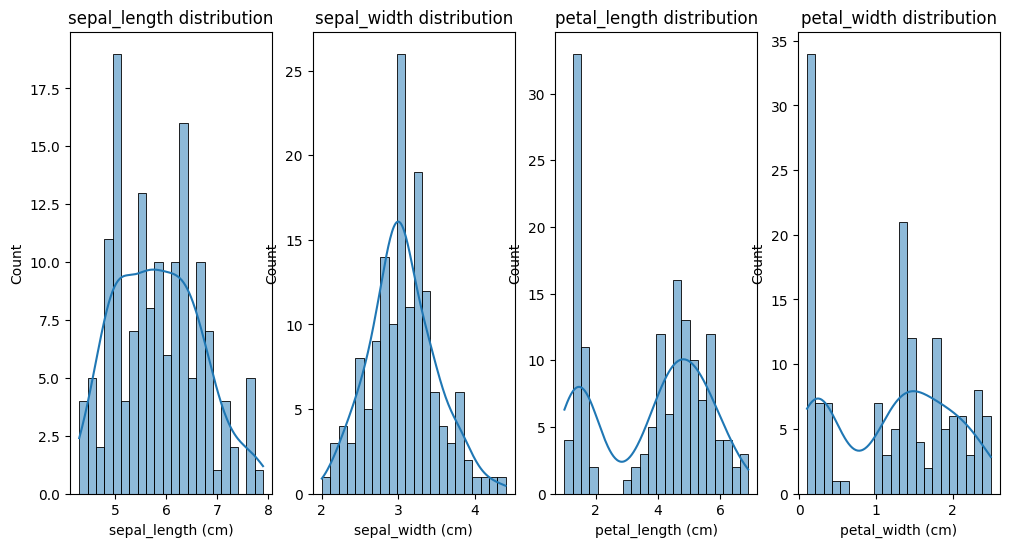

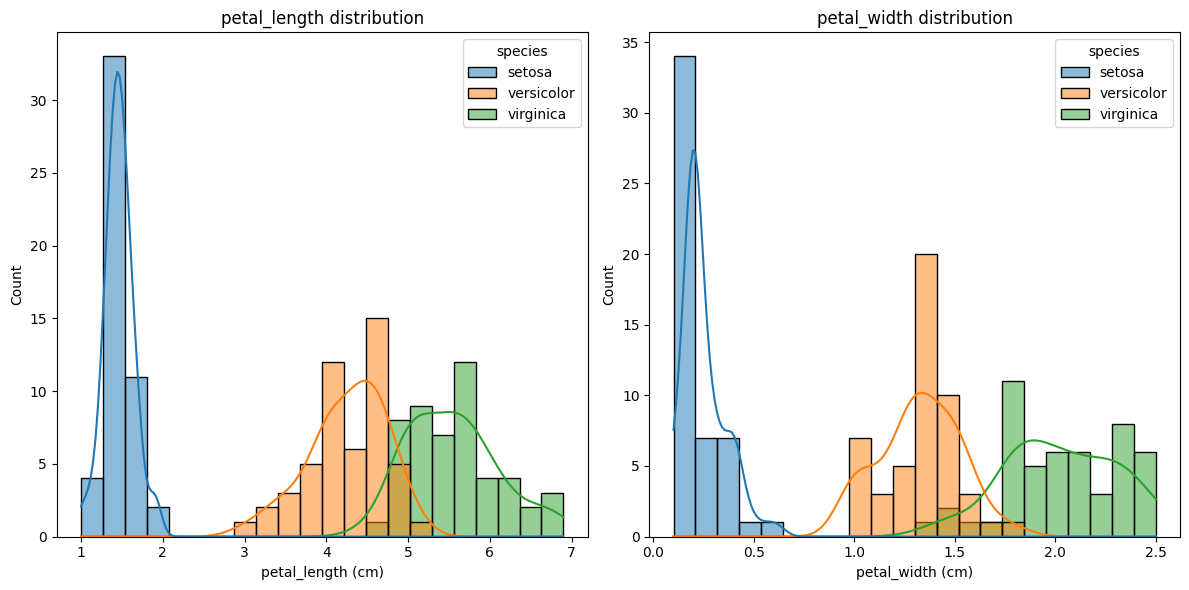

In [3]:
# Task 1
fig, ax = plt.subplots(1, 4, figsize=(12, 6))
label = ["sepal_length", "sepal_width", "petal_length", "petal_width"]
for i in range(4):
    sns.histplot(data=df, x=label[i], kde=True, bins=22, ax=ax[i]) 
    ax[i].set_title(f"{label[i]} distribution")
    ax[i].set_xlabel(f"{label[i]} (cm)")

fig, ax = plt.subplots(1, 2, figsize=(12, 6))
for i in range(2):
    sns.histplot(data=df, x=label[i+2], hue="species", kde=True, bins=22, ax=ax[i]) 
    ax[i].set_title(f"{label[i+2]} distribution")
    ax[i].set_xlabel(f"{label[i+2]} (cm)")

plt.tight_layout()
plt.show()

## Task 2
Virginica generally has larger measurements than Versicolor across all four features.
Setosa has the largest sepal width. However, for the other three features (sepal length, petal length, and petal width), it has the smallest measurements among the three species.

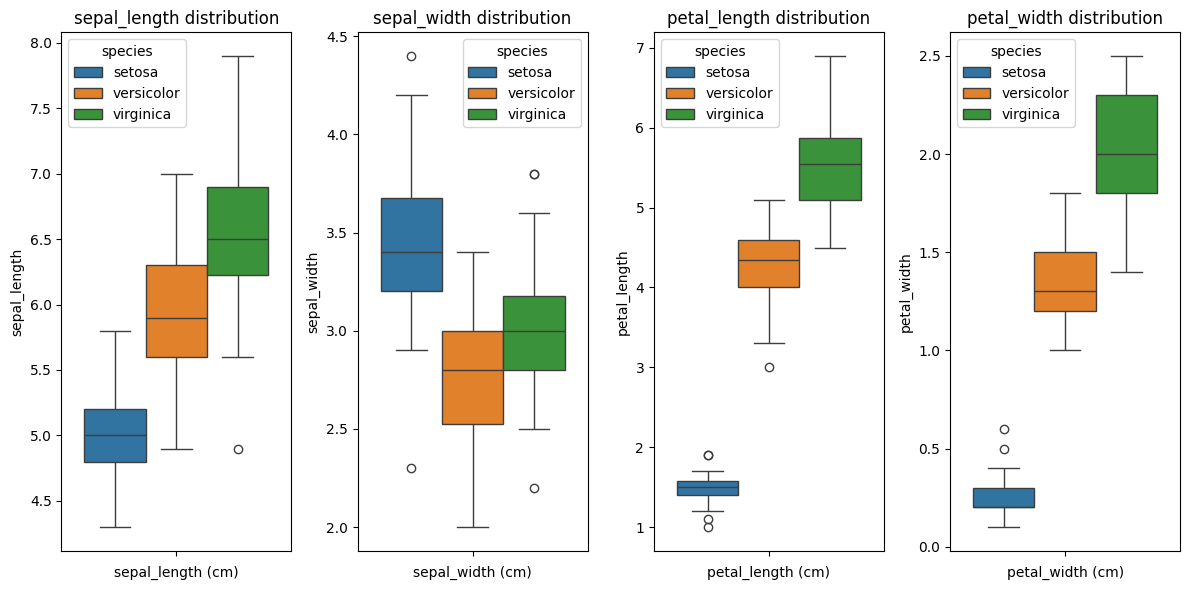

In [4]:
# Task 2
fig, ax = plt.subplots(1, 4, figsize=(12,6))
for i in range(4):
    sns.boxplot(data=df, y=label[i], hue="species", ax=ax[i])
    ax[i].set_title(f"{label[i]} distribution")
    ax[i].set_xlabel(f"{label[i]} (cm)")

plt.tight_layout()
plt.show()

## Task 3
I choose sepal_width to compare with PDF theoretical
As shown in the figure, the histogram and the theoretical Normal PDF have a similar bell-shaped pattern and peak near the same mean value. Although there are slight deviations, especially in the tails, the theoretical PDF fits the observed data reasonably well.

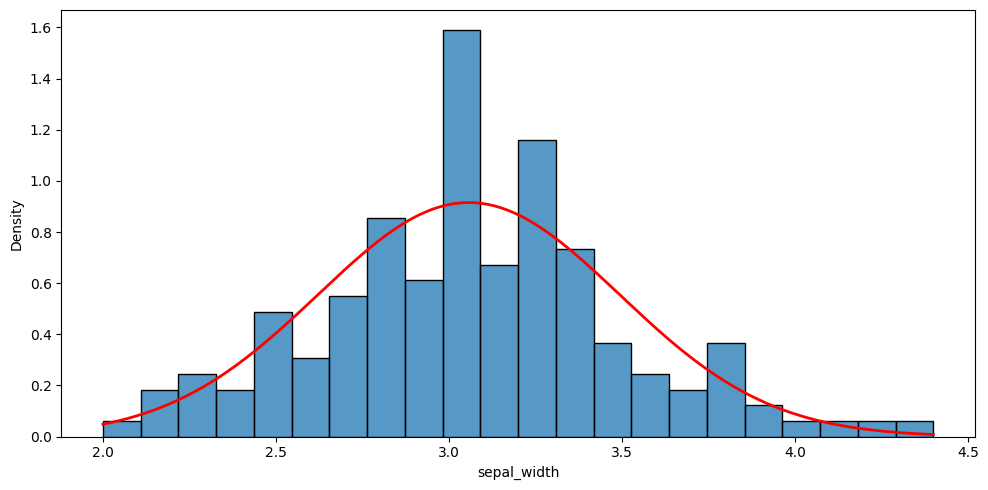

In [5]:
# Task 3
mean_sepal_length = mean["sepal_width"]
std_sepal_length = std["sepal_width"]
x = np.linspace(
    df["sepal_width"].min(),
    df["sepal_width"].max(),
    200
)
pdf = (
    1 / (std_sepal_length * np.sqrt(2*np.pi))
    * np.exp(-0.5 * ((x - mean_sepal_length) / std_sepal_length) ** 2)
)
fig = plt.figure(figsize=(10,5))
sns.histplot(data=df, x="sepal_width", stat="density", bins=22)
plt.plot(x, pdf, color="red", linewidth=2)

plt.tight_layout()
plt.show()

# PROBLEM 3

## Task 1

In [6]:
# Task 1
numeric_col = ["sepal_length", "sepal_width", "petal_length", "petal_width"]
cov = df[numeric_col].cov()
corr = df[numeric_col].corr()
cov_matrix = cov.to_numpy()
corr_matrix = corr.to_numpy()
print(f"Covariance:\n{cov_matrix}\n")
print(f"Correlation:\n{corr_matrix}\n")

Covariance:
[[ 0.68569351 -0.042434    1.27431544  0.51627069]
 [-0.042434    0.18997942 -0.32965638 -0.12163937]
 [ 1.27431544 -0.32965638  3.11627785  1.2956094 ]
 [ 0.51627069 -0.12163937  1.2956094   0.58100626]]

Correlation:
[[ 1.         -0.11756978  0.87175378  0.81794113]
 [-0.11756978  1.         -0.4284401  -0.36612593]
 [ 0.87175378 -0.4284401   1.          0.96286543]
 [ 0.81794113 -0.36612593  0.96286543  1.        ]]



## Task 2
The heatmap shows that petal_length and petal_width have the strongest positive correlation (r = 0.963). This indicates that flowers with longer petals generally also have wider petals. Since the correlation coefficient is very close to 1, these two variables show a strong indication of multicollinearity.

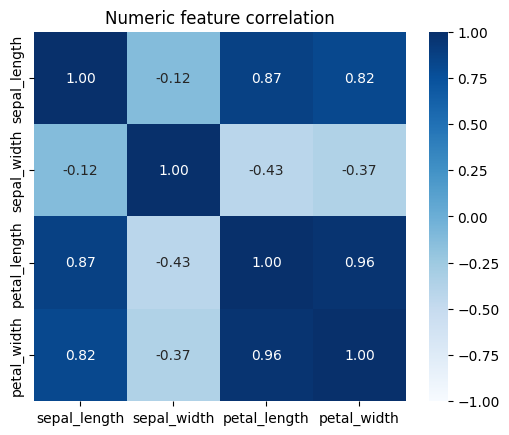

In [7]:
# Task 2
fig, ax = plt.subplots(figsize=(6, 4.8))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="Blues", vmin=-1, vmax=1, ax=ax)
ax.set_title("Numeric feature correlation")
plt.show()

## Task 3
The pairplot reveals several relationships among the four features. Petal length and petal width have the strongest positive linear relationship, indicating that flowers with longer petals generally have wider petals. Sepal length is also positively correlated with both petal features, whereas sepal width shows a weak negative correlation with them.
Regarding species separation, Setosa forms a clearly distinct cluster, especially in the petal-related plots. Versicolor and Virginica overlap slightly, particularly in the sepal features, but are better separated by petal length and petal width. Therefore, the petal features are the most informative variables for distinguishing Iris species.

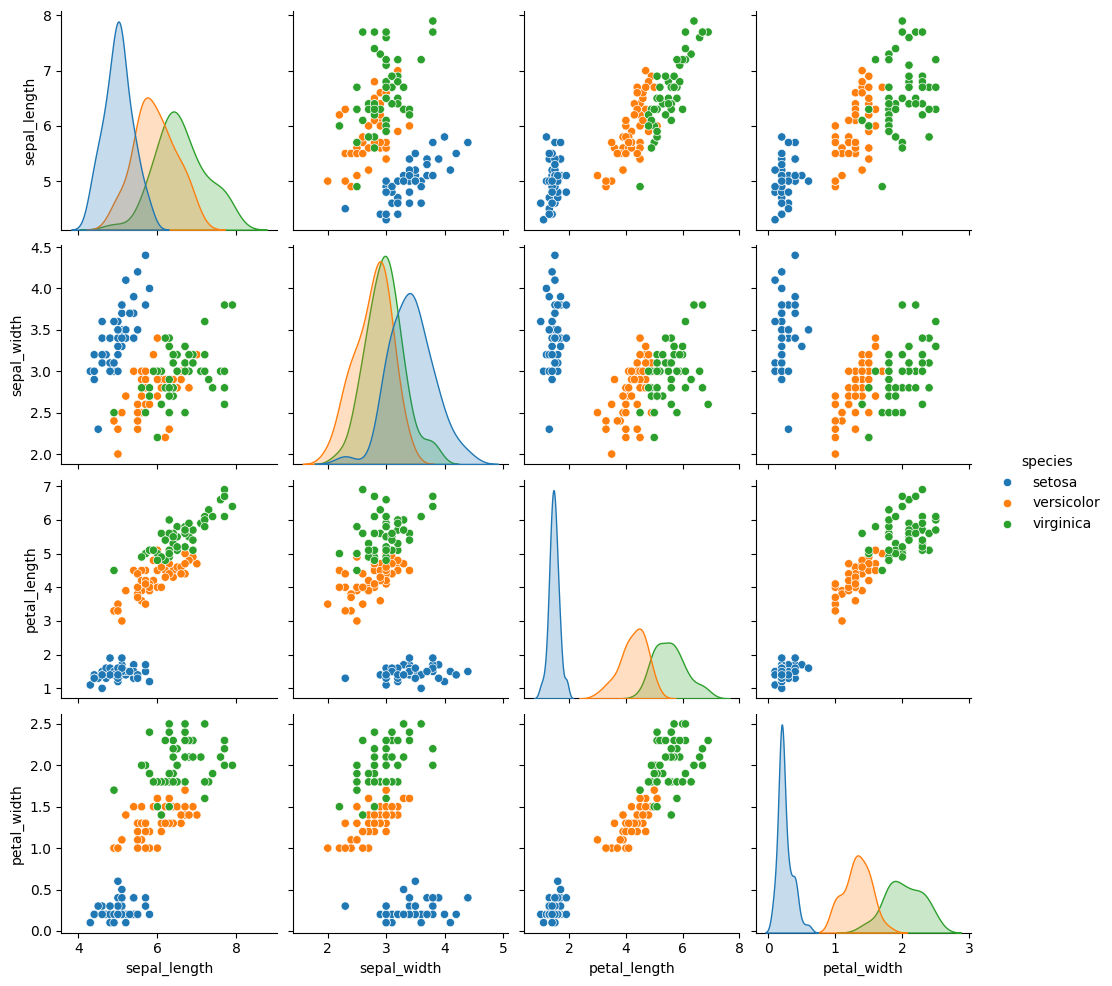

In [8]:
# Task 3
sns.pairplot(
    df,
    vars=numeric_col,
    hue="species"
)
plt.show()

# PROBLEM 4

## Task 1

In [9]:
import numpy as np
import matplotlib.pyplot as plt

p_B = np.linspace(0.001, 0.2, 200)
p_pos_givenB = 0.99
p_pos_givenNB = 0.05
print(round((0.99*0.01) / (0.99*0.01 + 0.05*0.99), 4)) # Task 1

0.1667


## Task 2
Theo em hiểu tính "phản trực giác" mà câu hỏi đề cập là nghịch lý vì sao độ chính xác của test tức là P(+|B) cao nhưng khi tỉ lệ bệnh tức P(B) thấp thì xác suất mắc bệnh khi test dương tính tức P(B|+) lại thấp. Đáng lí ra khi số người mắc bệnh ít và độ chính xác test cao thì test này phải phát hiện chính xác người bệnh hơn. Điều "phản trực giác" được lí giải do khi tỉ lệ bệnh thấp tức số người không mắc bệnh rất nhiều. Từ đó khi lượng người không mắc bệnh đủ nhiều thì số lượng người dương tính giả cũng sẽ rất lớn và có thể áp đảo số người dương tính thật. Vì thế mà dù cho độ chính xác cao nhưng tỉ lệ bệnh thấp thì kết quả test dương tính cũng không đáng tin cậy, cần phải test thêm nhiều lần nữa.

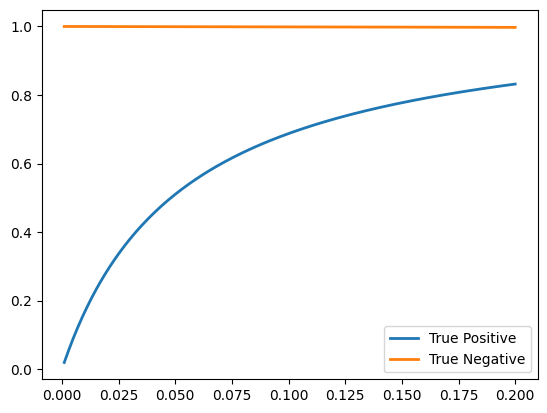

In [10]:
# Task 2
p_B_givenpos = (p_pos_givenB * p_B) / (p_pos_givenB * p_B + p_pos_givenNB * (1-p_B))

p_NB_givenNpos = ((1-p_pos_givenNB) * (1-p_B)) / ((1-p_pos_givenNB) * (1-p_B) + (1-p_pos_givenB) * p_B)

plt.plot(p_B, p_B_givenpos, label="True Positive", linewidth=2)
plt.plot(p_B, p_NB_givenNpos, label="True Negative", linewidth=2)
plt.legend()
plt.show()